# Session 2: Working with LLM Coding Agents

## Overview

This assignment explores how large language models function as coding agents within integrated development environments. You'll work with climate emissions data to understand both the capabilities and limitations of LLM-assisted data analysis, with particular attention to how execution environment shapes what's possible.

## Learning Objectives

Through structured exercises with the OWID CO2 dataset, you will:

- **Distinguish** between chat-based LLM interfaces and coding agents with local execution capabilities
- **Develop** fluency in specifying data operations through natural language while understanding the underlying computational patterns
- **Evaluate** the boundary between tasks coding agents handle autonomously versus those requiring human guidance
- **Assess** when programmatic approaches offer advantages over manual analysis methods

## The Execution Environment Question

The same foundation model—Claude Sonnet 4.5, GPT-4, or similar—exhibits markedly different capabilities depending on its execution context. A browser-based chat interface can generate syntactically correct code but lacks the infrastructure to execute, test, and refine it. The model generates a response and moves on.

In contrast, a coding agent operating within VS Code has access to a Python interpreter, your installed packages, the filesystem, and terminal. This enables an iterative cycle: execute code, parse errors or unexpected output, modify the approach, and re-execute. The model maintains context across this loop, accumulating information about what works in your specific environment.

This architectural difference—not model sophistication—determines whether you can request "analyze emissions trends by region" and receive working results, or whether you must manually execute generated code, diagnose failures, and prompt for corrections.

## Working with OWID Climate Data

Our World in Data maintains a comprehensive CO2 emissions dataset with country-level historical data, fuel source breakdowns, and economic indicators. The dataset's accessible format (direct CSV URL, documented schema, standard tabular structure) makes it appropriate for examining how coding agents handle common analytical workflows: filtering, aggregation, reshaping, and visualization.

Your role is to specify analyses in natural language and observe how the coding agent approaches each task. Note what it handles autonomously, where it requires clarification, what libraries it selects, and how it recovers from errors.

---
## Part 0: Setup

Import the necessary libraries for data manipulation and visualization. Request this from your coding agent and observe library selection.

In [1]:
# Setup - import libraries
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Display settings for readable output
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

print(f"pandas {pd.__version__} | numpy {np.__version__} | matplotlib {matplotlib.__version__}")

pandas 2.3.3 | numpy 2.5.2 | matplotlib 3.11.1


---
## Part 1: Loading and Initial Exploration

### Task 1.1: Load and Explore

Load the OWID CO2 dataset: `https://github.com/owid/co2-data/raw/master/owid-co2-data.csv`

Request from your coding agent:
1. Load the data using appropriate library
2. Report dimensions (rows × columns)
3. Identify temporal coverage
4. Display sample rows
5. List emissions-related columns

In [2]:
# Task 1.1 - Load and explore the OWID CO2 dataset
URL = "https://github.com/owid/co2-data/raw/master/owid-co2-data.csv"

# 1. Load the data directly from the URL
df = pd.read_csv(URL)

# 2. Report dimensions (rows x columns)
print(f"Dimensions: {df.shape[0]} rows x {df.shape[1]} columns")

# 3. Identify temporal coverage
print(f"Temporal coverage: {df['year'].min()} - {df['year'].max()}")

# 4. Display sample rows
display(df.head())

# 5. List emissions-related columns
emissions_cols = [
    c for c in df.columns
    if any(k in c.lower() for k in ["co2", "ghg", "methane", "nitrous"])
]
print(f"Emissions-related columns ({len(emissions_cols)}):")
for c in emissions_cols:
    print(f"  - {c}")

Dimensions: 50411 rows x 79 columns
Temporal coverage: 1750 - 2024


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_gas_co2,cumulative_luc_co2,cumulative_oil_co2,cumulative_other_co2,energy_per_capita,energy_per_gdp,flaring_co2,flaring_co2_per_capita,gas_co2,gas_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,other_co2_per_capita,other_industry_co2,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,"2,802,560.00",NaN,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Emissions-related columns (69):
  - cement_co2
  - cement_co2_per_capita
  - co2
  - co2_growth_abs
  - co2_growth_prct
  - co2_including_luc
  - co2_including_luc_growth_abs
  - co2_including_luc_growth_prct
  - co2_including_luc_per_capita
  - co2_including_luc_per_gdp
  - co2_including_luc_per_unit_energy
  - co2_per_capita
  - co2_per_gdp
  - co2_per_unit_energy
  - coal_co2
  - coal_co2_per_capita
  - consumption_co2
  - consumption_co2_per_capita
  - consumption_co2_per_gdp
  - cumulative_cement_co2
  - cumulative_co2
  - cumulative_co2_including_luc
  - cumulative_coal_co2
  - cumulative_flaring_co2
  - cumulative_gas_co2
  - cumulative_luc_co2
  - cumulative_oil_co2
  - cumulative_other_co2
  - flaring_co2
  - flaring_co2_per_capita
  - gas_co2
  - gas_co2_per_capita
  - ghg_excluding_lucf_per_capita
  - ghg_per_capita
  - land_use_change_co2
  - land_use_change_co2_per_capita
  - methane
  - methane_per_capita
  - nitrous_oxide
  - nitrous_oxide_per_capita
  - oil_co2
  - oil_

### Task 1.2: Filtering and Ranking

Identify the top 5 CO2 emitting countries (not aggregate regions) in 2022.

**Note:** Dataset includes aggregate entities (World, continents, income groups). The coding agent needs to distinguish actual countries - observe whether it infers this from ISO codes or requires explicit guidance.

In [3]:
# Task 1.2 - Top 5 CO2 emitting countries in 2022 (exclude aggregate regions)
# Note: 'iso_code' is NaN for aggregates (World, continents, income groups),
# so filtering on it keeps only actual countries.
countries_2022 = (
    df[(df["year"] == 2022) & (df["iso_code"].notna())]
    .dropna(subset=["co2"])
    .sort_values("co2", ascending=False)
)

top5 = countries_2022.head(5)[["country", "iso_code", "co2"]].reset_index(drop=True)
print("Top 5 CO2 emitting countries, 2022:")
display(top5)

Top 5 CO2 emitting countries, 2022:


,country,iso_code,co2
0,China,CHN,"11,711.81"
1,United States,USA,"5,055.40"
2,India,IND,"2,831.13"
3,Russia,RUS,"1,675.46"
4,Japan,JPN,"1,029.64"


### Task 1.3: Time Series Visualization

Create a line chart showing CO2 emissions trajectories for the top 5 emitters (1990-2022).

**Expected observation:** China overtaking US around 2005-2006.

**What to notice:** Does the agent select appropriate visualization library? Handle missing data? Create informative labels?

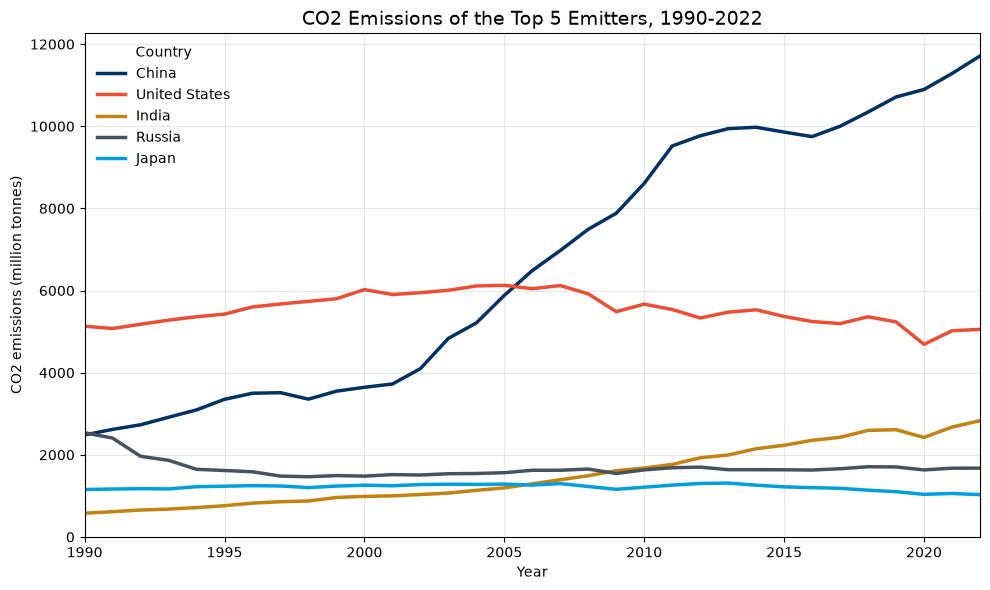

In [4]:
# Task 1.3 - CO2 emissions trajectories for top 5 emitters (1990-2022)
top5_names = top5["country"].tolist()

trajectory = (
    df[(df["country"].isin(top5_names)) & (df["year"] >= 1990) & (df["year"] <= 2022)]
    .dropna(subset=["co2"])
    .sort_values(["country", "year"])
)

# Berkeley line colors
line_colors = ["#003262", "#ED4E33", "#C4820E", "#46535E", "#00A0DF"]

fig, ax = plt.subplots(figsize=(10, 6))
for i, ctry in enumerate(top5_names):
    sub = trajectory[trajectory["country"] == ctry]
    ax.plot(sub["year"], sub["co2"], lw=2.5, label=ctry, color=line_colors[i])

ax.set_title("CO2 Emissions of the Top 5 Emitters, 1990-2022", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("CO2 emissions (million tonnes)")
ax.legend(title="Country", frameon=False)
ax.grid(alpha=0.3)
ax.set_xlim(1990, 2022)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

### Task 1.4: Compositional Analysis

For the top 5 countries in 2022, visualize emissions breakdown by source:
- Coal (`coal_co2`)
- Oil (`oil_co2`)
- Gas (`gas_co2`)  
- Cement (`cement_co2`)

Use a stacked bar chart or equivalent compositional visualization.

**Data reshaping challenge:** This requires pivoting from wide format (separate columns per source) to long format (source as variable). The coding agent should handle this transformation autonomously.

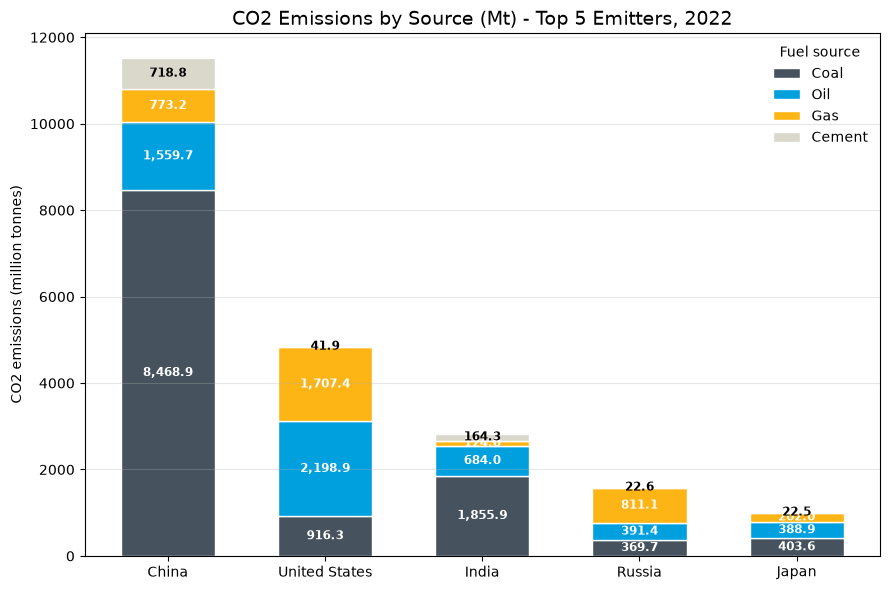

In [5]:
# Task 1.4 - Emissions breakdown by source for top 5 emitters (2022)
source_cols = ["coal_co2", "oil_co2", "gas_co2", "cement_co2"]
top5_names = top5["country"].tolist()

wide = (
    df[(df["country"].isin(top5_names)) & (df["year"] == 2022)]
    [["country"] + source_cols]
    .reset_index(drop=True)
)

long = wide.melt(
    id_vars="country", value_vars=source_cols,
    var_name="source", value_name="co2_mt",
).dropna(subset=["co2_mt"])
long["source"] = long["source"].map({
    "coal_co2": "Coal", "oil_co2": "Oil",
    "gas_co2": "Gas", "cement_co2": "Cement",
})

# Pivot to a matrix of countries x fuels for stacking
piv = long.pivot(index="country", columns="source", values="co2_mt")
piv = piv.reindex(columns=["Coal", "Oil", "Gas", "Cement"]).fillna(0)
piv = piv.reindex(index=top5_names).reset_index()

berkeley_sources = ["Coal", "Oil", "Gas", "Cement"]
berkeley_colors = ["#46535E", "#00A0DF", "#FDB515", "#DAD7CB"]

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(piv))
bottom = np.zeros(len(piv))

for src, color in zip(berkeley_sources, berkeley_colors):
    vals = piv[src].values
    ax.bar(x, vals, bottom=bottom, label=src, color=color,
           width=0.6, edgecolor="white")
    # Dark text on light segments (cement = Bay Fog), white on dark segments
    label_color = "black" if color == "#DAD7CB" else "white"
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0:
            ax.text(xi, b + v / 2, f"{v:,.1f}", ha="center", va="center",
                    color=label_color, fontsize=8.5, fontweight="bold")
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(piv["country"])
ax.set_title("CO2 Emissions by Source (Mt) - Top 5 Emitters, 2022", fontsize=14)
ax.set_ylabel("CO2 emissions (million tonnes)")
ax.legend(title="Fuel source", frameon=False)
ax.grid(alpha=0.3, axis="y")
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

---
## Part 2: Advanced Operations

### Task 2.1: Aggregation by Grouping Variable

Calculate average per capita CO2 emissions by continent for 2022. Return results sorted descending.

**Key operation:** This requires `groupby()` with aggregation. The coding agent should:
1. Identify the continent variable in the schema
2. Filter to 2022 and valid per capita values
3. Compute mean by group
4. Handle missing data appropriately

In [6]:
# Task 2.1 - Average per capita CO2 emissions by continent (2022)
# Continents are values in 'country' (there is no continent column).
continents = ["Africa", "Asia", "Europe", "North America", "Oceania", "South America"]

cont = (
    df[(df["year"] == 2022) & (df["country"].isin(continents))]
    .dropna(subset=["co2_per_capita"])
    [["country", "co2_per_capita"]]
)

by_continent = (
    cont.groupby("country", as_index=False)["co2_per_capita"]
    .mean()
    .sort_values("co2_per_capita", ascending=False)
    .reset_index(drop=True)
)
by_continent

,country,co2_per_capita
0,North America,10.39
1,Oceania,9.68
2,Europe,6.81
3,Asia,4.68
4,South America,2.56
5,Africa,1.01


### Task 2.2: Percentage Change Calculation

Identify countries with:
1. Five largest emission increases (2010→2022, percentage)
2. Five largest emission decreases (2010→2022, percentage)

Visualize both groups for comparison.

**Complexity:** Requires joining data across years, computing percentage change, handling countries with missing baseline or endpoint data. Observe error handling strategies.

Five largest emission increases (2010 -> 2022, %):


,country,co2_2010,co2_2022,pct_change
0,Laos,3.00,22.55,651.38
1,Tajikistan,2.54,10.52,315.03
2,Cambodia,5.07,20.86,311.78
3,Nepal,4.83,17.61,264.73
4,Mozambique,2.64,9.30,252.39


Five largest emission decreases (2010 -> 2022, %):


,country,co2_2010,co2_2022,pct_change
0,Aruba,2.51,0.89,-64.57
1,Yemen,25.82,10.40,-59.70
2,Montserrat,0.06,0.03,-55.93
3,Ukraine,294.37,143.04,-51.41
4,Syria,62.06,31.42,-49.36


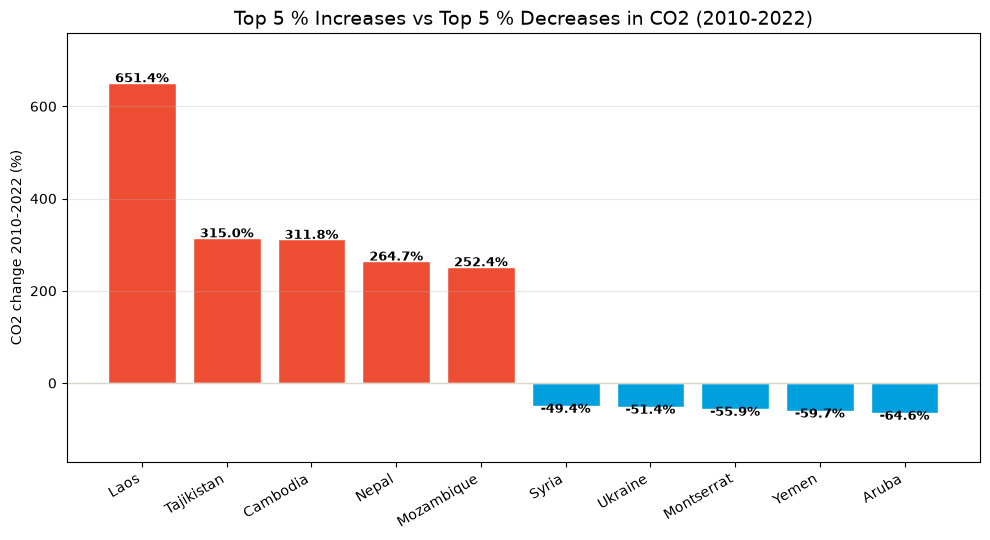

In [7]:
# Task 2.2 - Largest percentage emission changes (2010 -> 2022)
countries = df[df["iso_code"].notna()].copy()

# Pull the two years into wide columns (join across years)
y2010 = countries.loc[countries["year"] == 2010, ["country", "co2"]].rename(
    columns={"co2": "co2_2010"}
)
y2022 = countries.loc[countries["year"] == 2022, ["country", "co2"]].rename(
    columns={"co2": "co2_2022"}
)

merged = y2010.merge(y2022, on="country", how="inner")
merged = merged.dropna(subset=["co2_2010", "co2_2022"])

# Percentage change, guarding against zero/NaN baselines
merged["pct_change"] = ((merged["co2_2022"] - merged["co2_2010"]) / merged["co2_2010"]) * 100
valid = merged[np.isfinite(merged["pct_change"])].copy()

increases = valid.nlargest(5, "pct_change")[["country", "co2_2010", "co2_2022", "pct_change"]].reset_index(drop=True)
decreases = valid.nsmallest(5, "pct_change")[["country", "co2_2010", "co2_2022", "pct_change"]].reset_index(drop=True)

print("Five largest emission increases (2010 -> 2022, %):")
display(increases)
print("Five largest emission decreases (2010 -> 2022, %):")
display(decreases)

# Order: greatest increase (left) -> greatest decrease (right)
both = pd.concat([
    increases.assign(group="Increase"),
    decreases.assign(group="Decrease"),
])
both["label"] = both["pct_change"].round(1).astype(str) + "%"
both = both.sort_values("pct_change", ascending=False).reset_index(drop=True)

# Berkeley colors: Golden Gate (increase) vs Lap Lane (decrease)
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(both))
colors = ["#ED4E33" if g == "Increase" else "#00A0DF" for g in both["group"]]
ax.bar(x, both["pct_change"], color=colors, edgecolor="white")

# Zero reference line
ax.axhline(0, color="#DAD7CB", lw=1)

# Data labels above (increase) / below (decrease) the bar tip
for xi, (v, lab) in enumerate(zip(both["pct_change"], both["label"])):
    ax.text(xi, v + (8 if v >= 0 else -8), lab, ha="center", va="center",
            fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(both["country"], rotation=30, ha="right")
ax.set_title("Top 5 % Increases vs Top 5 % Decreases in CO2 (2010-2022)", fontsize=14)
ax.set_ylabel("CO2 change 2010-2022 (%)")
ax.grid(alpha=0.3, axis="y")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

### Task 2.3: Faceted Visualization

Create small multiples showing per capita CO2 trends (1990-2022) with one panel per continent.

**Visualization technique:** Faceting/small multiples allow pattern comparison across categories. The coding agent should select appropriate library (Altair, matplotlib with subplots, etc.) and configure layout.

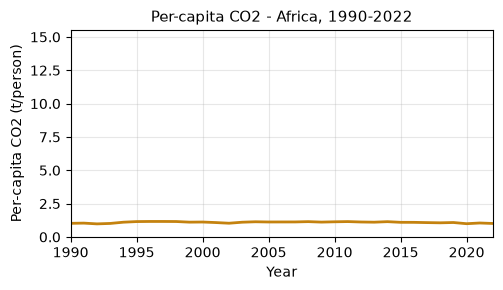

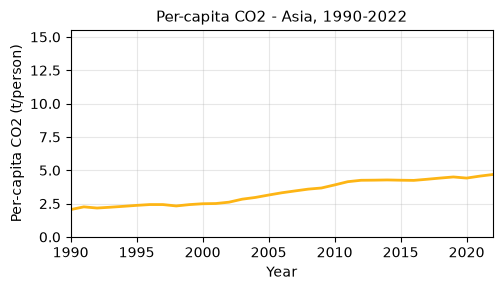

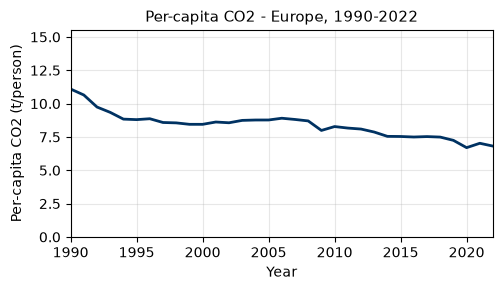

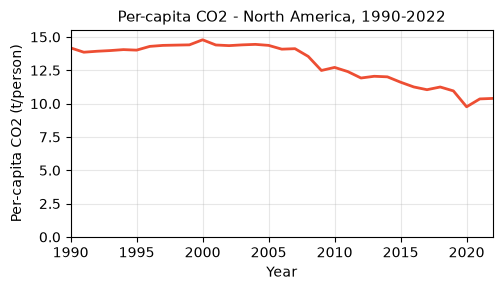

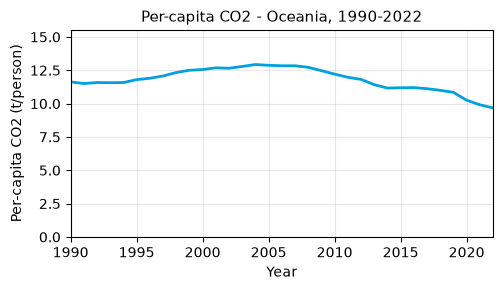

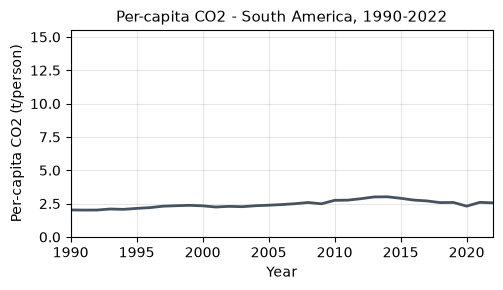

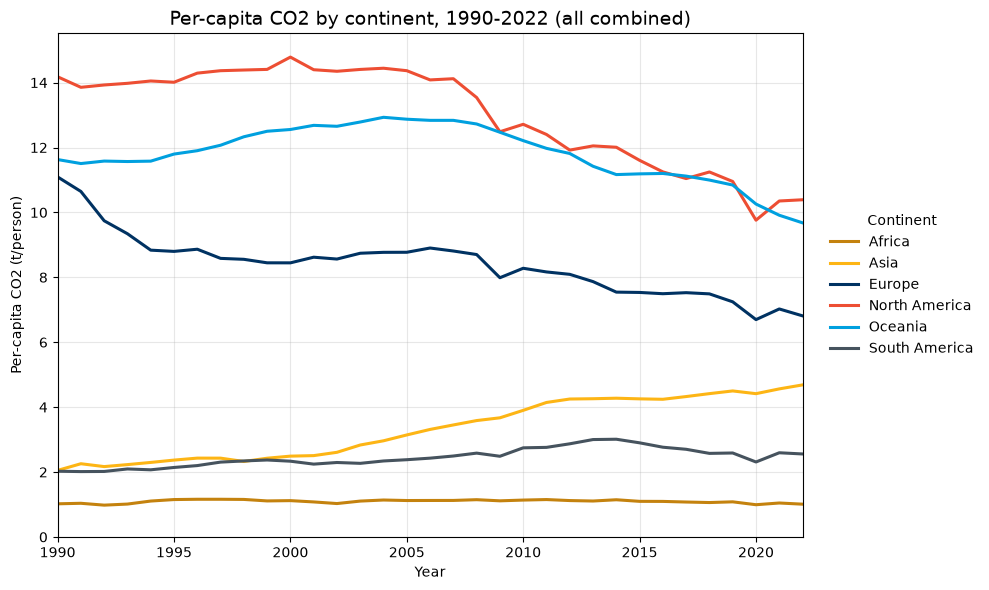

In [8]:
# Task 2.3 - Per-capita CO2 trends by continent (1990-2022)
continents = ["Africa", "Asia", "Europe", "North America", "Oceania", "South America"]

trend = (
    df[(df["country"].isin(continents)) & (df["year"] >= 1990) & (df["year"] <= 2022)]
    .dropna(subset=["co2_per_capita"])
    [["country", "year", "co2_per_capita"]]
    .sort_values(["country", "year"])
)

# Berkeley color scheme, one color per continent
berkeley_colors = {
    "Africa":        "#C4820E",   # Medalist
    "Asia":          "#FDB515",   # California Gold
    "Europe":        "#003262",   # Berkeley Blue
    "North America": "#ED4E33",   # Golden Gate
    "Oceania":       "#00A0DF",   # Lap Lane
    "South America": "#46535E",   # Stone Pine
}

# Shared Y window across all six panels (so the same scale is used on every chart)
y_max = trend["co2_per_capita"].max()
y_window = (0, y_max * 1.05)

# 6 individual charts, one per continent (same Y axis on each, full X axis)
for continent in continents:
    sub = trend[trend["country"] == continent].sort_values("year")
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.plot(sub["year"], sub["co2_per_capita"], lw=2, color=berkeley_colors[continent])
    ax.set_title(f"Per-capita CO2 - {continent}, 1990-2022", fontsize=11)
    ax.set_xlabel("Year")
    ax.set_ylabel("Per-capita CO2 (t/person)")
    ax.grid(alpha=0.3)
    ax.set_xlim(1990, 2022)
    ax.set_ylim(y_window)
    plt.tight_layout()
    plt.show()

# 1 combined chart: all continents overlaid, legend via color
fig, ax = plt.subplots(figsize=(10, 6))
for continent in continents:
    sub = trend[trend["country"] == continent].sort_values("year")
    ax.plot(sub["year"], sub["co2_per_capita"], lw=2.2,
            label=continent, color=berkeley_colors[continent])

ax.set_title("Per-capita CO2 by continent, 1990-2022 (all combined)", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Per-capita CO2 (t/person)")
ax.legend(title="Continent", frameon=False,
        loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(alpha=0.3)
ax.set_xlim(1990, 2022)
ax.set_ylim(y_window)
plt.tight_layout()
plt.show()

---
## Part 3: Independent Analysis

### Task 3.1: Design and Execute Analysis

Select ONE question and complete the analysis:

**Option A:** Emissions Intensity Improvements
- Identify countries with largest reductions in CO2 per unit GDP (2000-2022)
- Visualize as efficiency gains

**Option B:** Coal Transition Analysis
- Find countries that significantly reduced coal's share of total emissions (2010-2022)
- Show before/after fuel composition

**Option C:** Population-Emissions Relationship
- Analyze correlation between population growth and emissions growth
- Create annotated scatter plot highlighting outliers

**Deliverables:**
- Working code that executes without errors
- At least one publication-quality visualization
- Interpretation of findings and limitations

### My Analysis:

**Question I'm investigating (Option A):**
Which countries achieved the largest reductions in CO2 emissions per unit GDP between 2000 and 2022, and what does that reveal about "efficiency gains"?

**Question I'm investigating (Option B):**
Which countries most reduced coal's share of total emissions between 2010 and 2022, and what does their before/after fuel composition look like?

**Question I'm investigating (Option C):**
Is there a correlation between population growth and CO2 emissions growth (2000-2022), and which countries are the outliers?

**Choice:** I completed all three options: A (Emissions Intensity Improvements), B (Coal Transition Analysis), and C (Population-Emissions Relationship).

Countries with valid intensity data at both endpoints: 164


,country,intensity_2000,intensity_2022,efficiency_gain_pct
0,Angola,0.68,0.13,80.44
1,Qatar,1.34,0.29,78.58
2,Romania,0.59,0.14,75.47
3,Azerbaijan,0.87,0.23,72.96
4,Uzbekistan,1.06,0.30,71.31
5,Malta,0.31,0.10,68.71
6,Nigeria,0.36,0.12,67.87
7,Gabon,0.49,0.16,67.28
8,Hungary,0.43,0.16,63.36
9,Bahrain,1.74,0.64,62.99


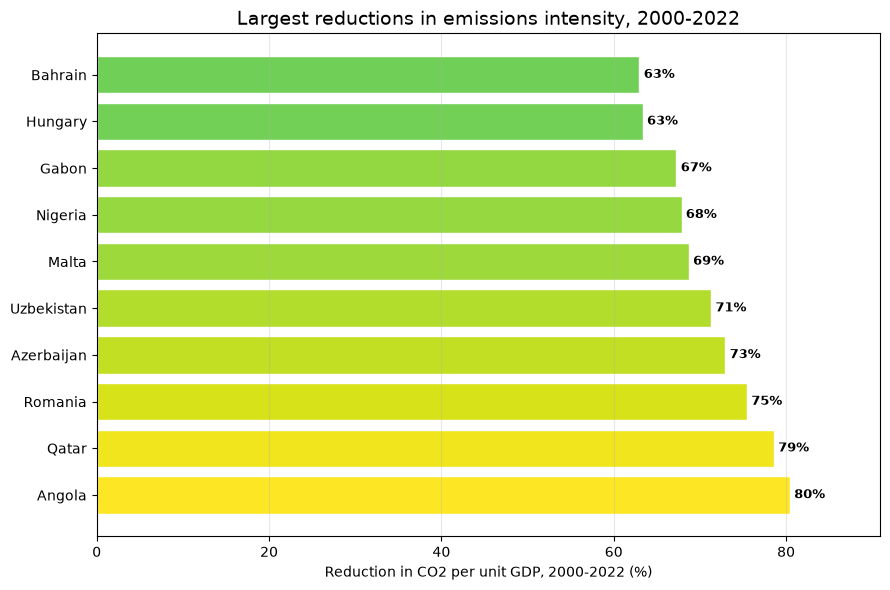

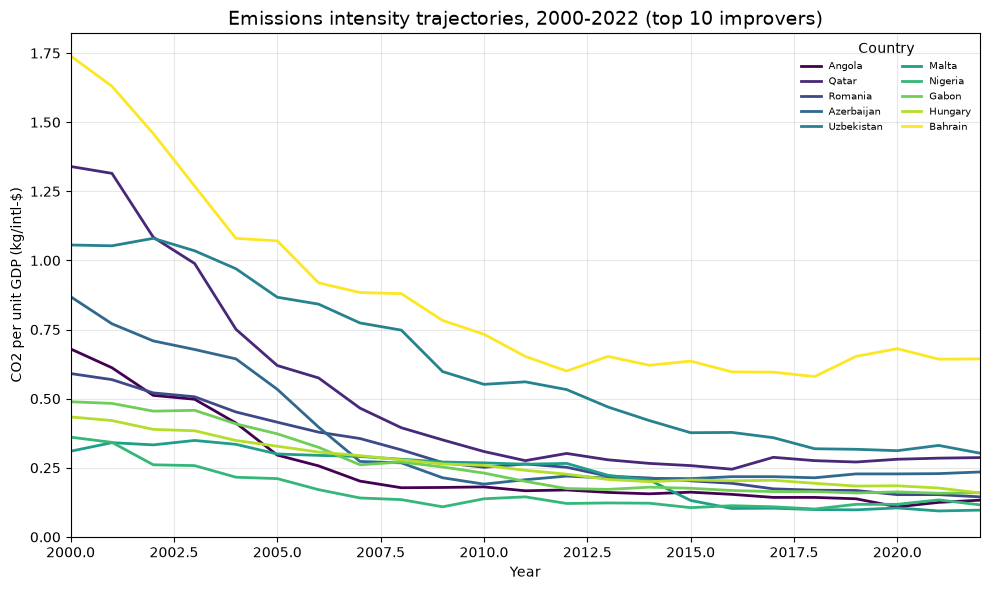

In [9]:
# Part 3, Option A - Emissions Intensity Improvements (2000-2022)
# Efficiency gain = reduction in CO2 per unit GDP (co2_per_gdp).
countries = df[df["iso_code"].notna()].copy()

int_2000 = countries.loc[countries["year"] == 2000, ["country", "co2_per_gdp"]].rename(
    columns={"co2_per_gdp": "intensity_2000"}
)
int_2022 = countries.loc[countries["year"] == 2022, ["country", "co2_per_gdp"]].rename(
    columns={"co2_per_gdp": "intensity_2022"}
)

merged = int_2000.merge(int_2022, on="country", how="inner")
merged = merged.dropna(subset=["intensity_2000", "intensity_2022"])

merged["pct_change"] = ((merged["intensity_2022"] - merged["intensity_2000"]) / merged["intensity_2000"]) * 100
merged = merged[np.isfinite(merged["pct_change"])].copy()
merged["efficiency_gain_pct"] = -merged["pct_change"]
merged = merged.sort_values("efficiency_gain_pct", ascending=False).reset_index(drop=True)

print(f"Countries with valid intensity data at both endpoints: {len(merged)}")
top10 = merged.head(10)[["country", "intensity_2000", "intensity_2022", "efficiency_gain_pct"]].reset_index(drop=True)
display(top10)

# --- Publication-quality visualization: horizontal bars with % labels ---
chart_top10 = top10.sort_values("efficiency_gain_pct", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 6))
ypos = np.arange(len(chart_top10))
norm = chart_top10["efficiency_gain_pct"] / chart_top10["efficiency_gain_pct"].max()
ax.barh(ypos, chart_top10["efficiency_gain_pct"],
        color=plt.cm.viridis(norm), edgecolor="white")
ax.set_yticks(ypos)
ax.set_yticklabels(chart_top10["country"])
ax.set_xlabel("Reduction in CO2 per unit GDP, 2000-2022 (%)")
ax.set_title("Largest reductions in emissions intensity, 2000-2022", fontsize=14)
for i, v in enumerate(chart_top10["efficiency_gain_pct"]):
    ax.text(v + 0.5, i, f"{v:.0f}%", va="center", fontsize=9, fontweight="bold")
ax.grid(alpha=0.3, axis="x")
ax.set_xlim(0, chart_top10["efficiency_gain_pct"].max() * 1.13)
plt.tight_layout()
plt.show()

# --- Trajectory line chart: intensity over time for the same top 10 ---
top10_names = top10["country"].tolist()

traj = (
    countries[(countries["country"].isin(top10_names)) & (countries["year"] >= 2000) & (countries["year"] <= 2022)]
    .dropna(subset=["co2_per_gdp"])
    [["country", "year", "co2_per_gdp"]]
    .sort_values(["country", "year"])
)

cmap = plt.get_cmap("viridis")
fig, ax = plt.subplots(figsize=(10, 6))
for i, ctry in enumerate(top10_names):
    sub = traj[traj["country"] == ctry].sort_values("year")
    ax.plot(sub["year"], sub["co2_per_gdp"], lw=2,
            label=ctry, color=cmap(i / max(1, len(top10_names) - 1)))

ax.set_title("Emissions intensity trajectories, 2000-2022 (top 10 improvers)", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("CO2 per unit GDP (kg/intl-$)")
ax.legend(title="Country", frameon=False, fontsize=7, ncol=2)
ax.grid(alpha=0.3)
ax.set_xlim(2000, 2022)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

Top 10 countries by coal-share reduction (2010 -> 2022, percentage points):


,country,coal_share_2010,coal_share_2022,share_drop_pp
0,Greece,42.38,15.22,27.16
1,Eswatini,37.01,17.51,19.50
2,North Macedonia,63.84,45.20,18.64
3,Niger,28.45,9.84,18.61
4,Israel,41.11,23.34,17.76
5,Denmark,31.21,14.21,17.00
6,United Kingdom,23.06,6.42,16.64
7,United States,34.33,18.13,16.21
8,Romania,34.80,18.79,16.01
9,Zimbabwe,74.33,58.58,15.76


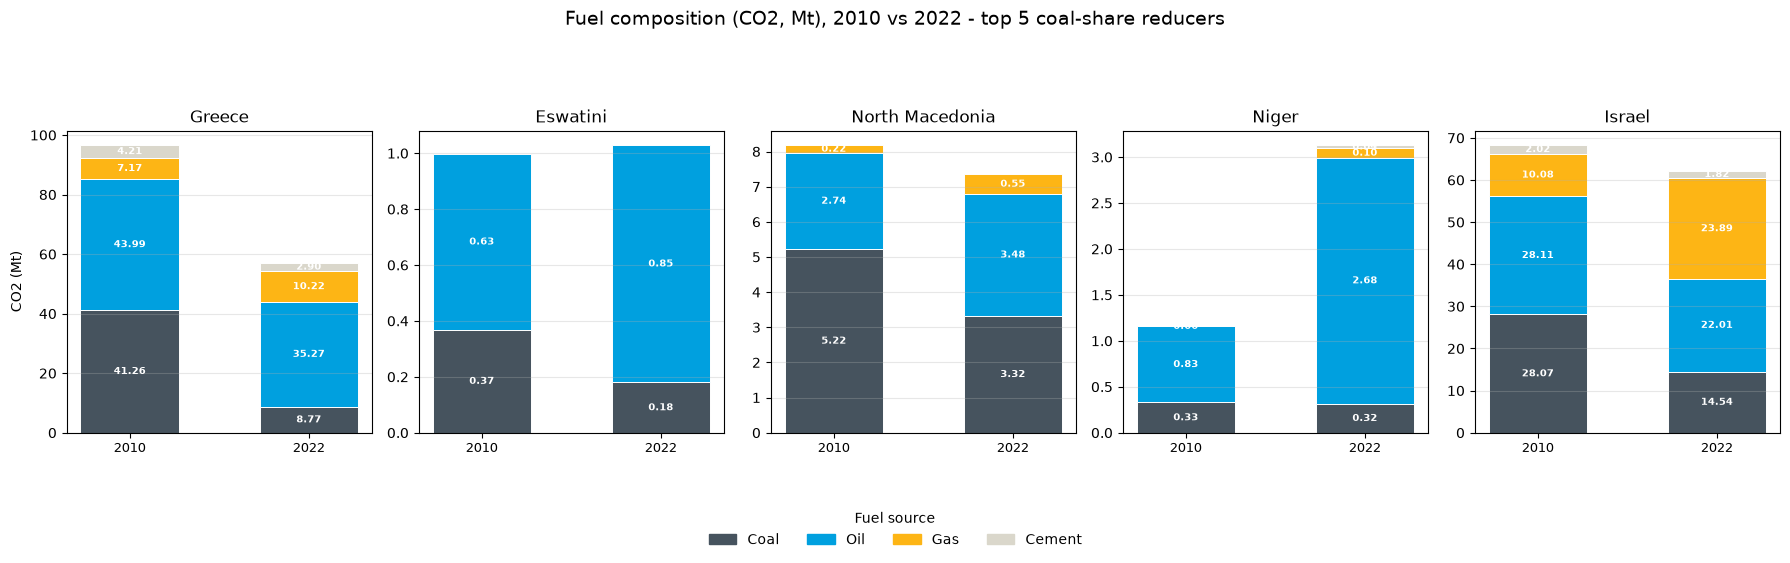

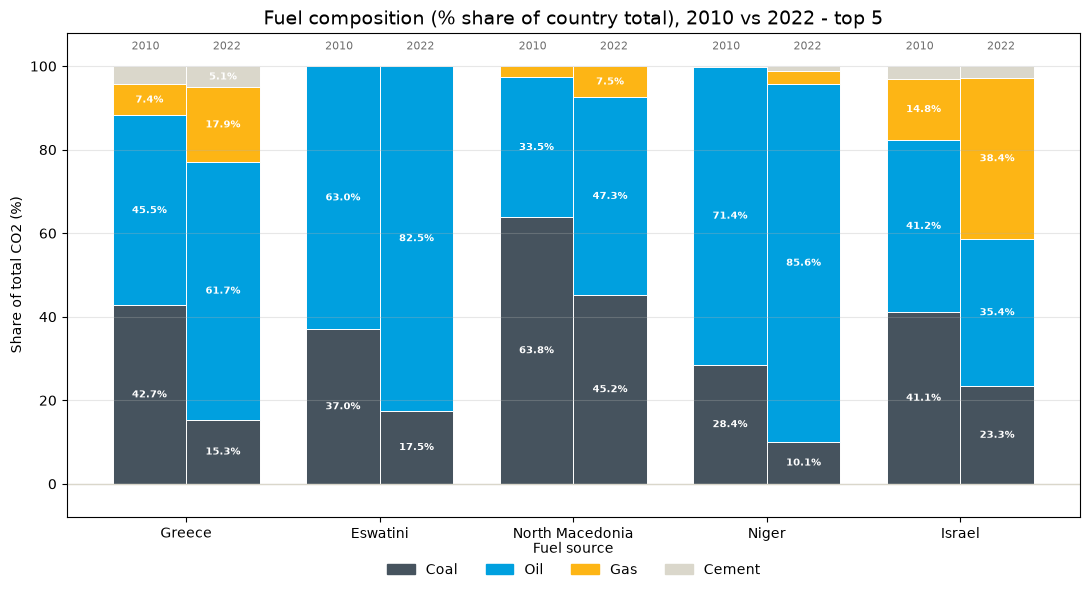

In [10]:
# Part 3, Option B - Coal Transition Analysis (2010-2022)
countries = df[df["iso_code"].notna()].copy()

# --- Coal share (% of total CO2 coming from coal) in 2010 and 2022 ---
def coal_share(year):
    sub = countries.loc[countries["year"] == year, ["country", "co2", "coal_co2"]].copy()
    sub["coal_share"] = sub["coal_co2"] / sub["co2"] * 100
    return sub[["country", "coal_share"]].rename(columns={"coal_share": f"coal_share_{year}"})

merged = coal_share(2010).merge(coal_share(2022), on="country", how="inner")
merged = merged.dropna(subset=["coal_share_2010", "coal_share_2022"])

# Reduction in coal's share (percentage points)
merged["share_drop_pp"] = merged["coal_share_2010"] - merged["coal_share_2022"]
merged = merged.sort_values("share_drop_pp", ascending=False).reset_index(drop=True)

# Require a meaningful starting coal footprint (>=20%) to avoid tiny-baseline noise
coal_reducers = merged[merged["coal_share_2010"] >= 20].head(10)
print("Top 10 countries by coal-share reduction (2010 -> 2022, percentage points):")
display(coal_reducers[["country", "coal_share_2010", "coal_share_2022", "share_drop_pp"]])

# --- Before/after fuel composition for the top 5 reducers ---
top5 = coal_reducers.head(5)["country"].tolist()
fuel_cols = ["coal_co2", "oil_co2", "gas_co2", "cement_co2"]

comp = (
    countries[(countries["country"].isin(top5)) & (countries["year"].isin([2010, 2022]))]
    [["country", "year"] + fuel_cols]
    .melt(id_vars=["country", "year"], value_vars=fuel_cols,
          var_name="source", value_name="co2_mt")
    .dropna(subset=["co2_mt"])
)
comp["year"] = comp["year"].astype(str)
comp["source"] = comp["source"].map({
    "coal_co2": "Coal", "oil_co2": "Oil",
    "gas_co2": "Gas", "cement_co2": "Cement",
})

# Fixed stack order (bottom -> top), computed manually in pandas
berkeley_sources = ["Coal", "Oil", "Gas", "Cement"]
berkeley_range = ["#46535E", "#00A0DF", "#FDB515", "#DAD7CB"]  # Stone Pine / Lap Lane / Cal Gold / Bay Fog
comp["source"] = pd.Categorical(comp["source"], categories=berkeley_sources, ordered=True)
comp = comp.sort_values(["country", "year", "source"]).reset_index(drop=True)

# Computed segments: absolute (Mt) and normalized (% of country-year total)
comp["total"] = comp.groupby(["country", "year"])["co2_mt"].transform("sum")
comp["pct"] = comp["co2_mt"] / comp["total"] * 100

# ============================================================================
# Chart 1: Mt per-country panels (independent scales, full-height bars,
# 2010/2022 side by side, every non-zero segment labeled)
# ============================================================================
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, ctry in zip(axes, top5):
    sub = comp[comp["country"] == ctry]
    xpos = np.arange(2)  # 2010, 2022
    for xi, yr in enumerate(["2010", "2022"]):
        sy = sub[sub["year"] == yr].sort_values("source")
        bottom = 0.0
        for src, color in zip(berkeley_sources, berkeley_range):
            row = sy[sy["source"] == src]
            v = float(row["co2_mt"].iloc[0]) if len(row) else 0.0
            if v > 0:
                ax.bar(xi, v, bottom=bottom, color=color, width=0.55,
                       edgecolor="white", linewidth=0.7)
                ax.text(xi, bottom + v / 2, f"{v:,.2f}", ha="center", va="center",
                        color="white", fontsize=7.5, fontweight="bold")
                bottom += v
            elif bottom == 0:
                pass
    ax.set_xticks(xpos)
    ax.set_xticklabels(["2010", "2022"], fontsize=9)
    ax.set_title(ctry, fontsize=12)
    ax.grid(alpha=0.3, axis="y")
    ax.set_ylim(bottom=0)
    ax.margins(y=0.12)

axes[0].set_ylabel("CO2 (Mt)")
fig.suptitle("Fuel composition (CO2, Mt), 2010 vs 2022 - top 5 coal-share reducers",
             fontsize=14)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in berkeley_range]
fig.legend(handles, berkeley_sources, title="Fuel source", loc="lower center",
           ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.12))
# Reserve explicit headroom at the top so the suptitle does not collide with
# the per-panel country titles, and room at the base for the shared legend.
fig.tight_layout(rect=[0, 0.06, 1, 0.88])
plt.show()

# ============================================================================
# Chart 2: normalized fuel share (%), grouped bars on a shared 0-100 scale
# ============================================================================
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(top5))
w = 0.38

for yi, (yr, xoff) in enumerate(zip(["2010", "2022"], [-w / 2, w / 2])):
    bottom = np.zeros(len(top5))
    for src, color in zip(berkeley_sources, berkeley_range):
        vals = np.array([
            comp[(comp["country"] == c) & (comp["year"] == yr) & (comp["source"] == src)]["pct"].iloc[0]
            if len(comp[(comp["country"] == c) & (comp["year"] == yr) & (comp["source"] == src)]) else 0.0
            for c in top5
        ])
        ax.bar(x + xoff, vals, bottom=bottom, width=w, color=color,
               edgecolor="white", linewidth=0.7,
               label=src if yr == "2010" else None)
        for xi, (v, b) in enumerate(zip(vals, bottom)):
            if v >= 5:
                ax.text(xi + xoff, b + v / 2, f"{v:.1f}%", ha="center", va="center",
                        color="white", fontsize=7.5, fontweight="bold")
        bottom += vals

# Year labels above each country's pair
for xi, ctry in enumerate(top5):
    ax.text(xi - w / 2 - 0.02, 104, "2010", ha="center", fontsize=8, color="#6d6d6d")
    ax.text(xi + w / 2 + 0.02, 104, "2022", ha="center", fontsize=8, color="#6d6d6d")

ax.set_xticks(x)
ax.set_xticklabels(top5)
ax.set_ylabel("Share of total CO2 (%)")
ax.set_ylim(-8, 108)
ax.set_title("Fuel composition (% share of country total), 2010 vs 2022 - top 5", fontsize=14)
ax.axhline(0, color="#DAD7CB", lw=1)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in berkeley_range]
ax.legend(handles, berkeley_sources, title="Fuel source", loc="lower center",
          ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.15))
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

Pearson correlation r = 0.327 over 213 countries
Continent coverage: {'Africa': 55, 'Asia': 51, 'Europe': 42, 'North America': 34, 'Oceania': 19, 'South America': 12}


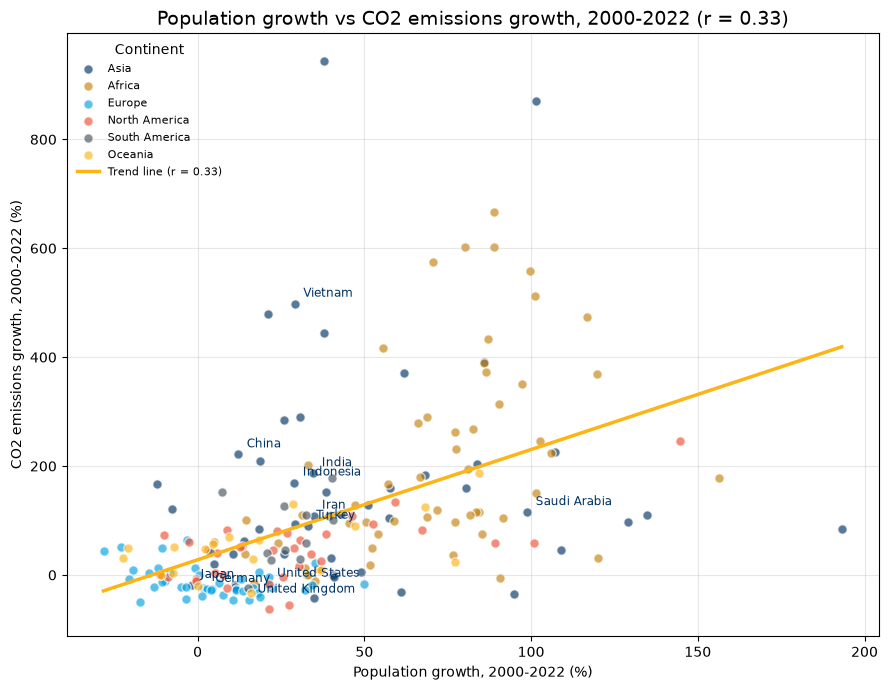

In [11]:
# Part 3, Option C - Population-Emissions Relationship (2000-2022)
countries = df[df["iso_code"].notna()].copy()

# --- Build growth rates: % change in population and in CO2 (2000 -> 2022) ---
def snap(year):
    return (
        countries.loc[countries["year"] == year, ["country", "iso_code", "population", "co2"]]
        .rename(columns={"population": f"pop_{year}", "co2": f"co2_{year}"})
    )

merged = snap(2000).merge(snap(2022), on="country", how="inner")
# iso_code exists in both frames -> pandas names them iso_code_x / iso_code_y
merged = merged.drop(columns=["iso_code_y"]).rename(columns={"iso_code_x": "iso_code"})
merged = merged.dropna(subset=["pop_2000", "pop_2022", "co2_2000", "co2_2022"])

# Percentage growth over the window
merged["pop_growth_pct"] = (merged["pop_2022"] / merged["pop_2000"] - 1) * 100
merged["co2_growth_pct"] = (merged["co2_2022"] / merged["co2_2000"] - 1) * 100
merged = merged[np.isfinite(merged["pop_growth_pct"]) & np.isfinite(merged["co2_growth_pct"])]
merged = merged.sort_values("co2_growth_pct", ascending=False).reset_index(drop=True)

# --- Pearson correlation: kept on the FULL sample (Laos and Qatar included) ---
corr = merged["pop_growth_pct"].corr(merged["co2_growth_pct"])
print(f"Pearson correlation r = {corr:.3f} over {len(merged)} countries")

# --- Continent lookup (ISO3 -> continent, embedded from Natural Earth 50m) ---
# ISO codes in the OWID data match Natural Earth's ISO_A3 / ADM0_A3 codes;
# a few tiny territories are patched by hand below.

CONTINENT_BY_ISO = {
    "ABW": "North America",
    "AFG": "Asia",
    "AGO": "Africa",
    "AIA": "North America",
    "ALA": "Europe",
    "ALB": "Europe",
    "AND": "Europe",
    "ANT": "North America",
    "ARE": "Asia",
    "ARG": "South America",
    "ARM": "Asia",
    "ASM": "Oceania",
    "ATA": "Antarctica",
    "ATG": "North America",
    "AUS": "Oceania",
    "AUT": "Europe",
    "AZE": "Asia",
    "BDI": "Africa",
    "BEL": "Europe",
    "BEN": "Africa",
    "BES": "North America",
    "BFA": "Africa",
    "BGD": "Asia",
    "BGR": "Europe",
    "BHR": "Asia",
    "BHS": "North America",
    "BIH": "Europe",
    "BLM": "North America",
    "BLR": "Europe",
    "BLZ": "North America",
    "BMU": "North America",
    "BOL": "South America",
    "BRA": "South America",
    "BRB": "North America",
    "BRN": "Asia",
    "BTN": "Asia",
    "BWA": "Africa",
    "CAF": "Africa",
    "CAN": "North America",
    "CHE": "Europe",
    "CHL": "South America",
    "CHN": "Asia",
    "CIV": "Africa",
    "CMR": "Africa",
    "COD": "Africa",
    "COG": "Africa",
    "COK": "Oceania",
    "COL": "South America",
    "COM": "Africa",
    "CPV": "Africa",
    "CRI": "North America",
    "CUB": "North America",
    "CUW": "North America",
    "CXR": "Oceania",
    "CYM": "North America",
    "CYP": "Asia",
    "CZE": "Europe",
    "DEU": "Europe",
    "DJI": "Africa",
    "DMA": "North America",
    "DNK": "Europe",
    "DOM": "North America",
    "DZA": "Africa",
    "ECU": "South America",
    "EGY": "Africa",
    "ERI": "Africa",
    "ESH": "Africa",
    "ESP": "Europe",
    "EST": "Europe",
    "ETH": "Africa",
    "FIN": "Europe",
    "FJI": "Oceania",
    "FLK": "South America",
    "FRA": "Europe",
    "FRO": "Europe",
    "FSM": "Oceania",
    "GAB": "Africa",
    "GBR": "Europe",
    "GEO": "Asia",
    "GGY": "Europe",
    "GHA": "Africa",
    "GIN": "Africa",
    "GMB": "Africa",
    "GNB": "Africa",
    "GNQ": "Africa",
    "GRC": "Europe",
    "GRD": "North America",
    "GRL": "North America",
    "GTM": "North America",
    "GUM": "Oceania",
    "GUY": "South America",
    "HKG": "Asia",
    "HND": "North America",
    "HRV": "Europe",
    "HTI": "North America",
    "HUN": "Europe",
    "IDN": "Asia",
    "IMN": "Europe",
    "IND": "Asia",
    "IRL": "Europe",
    "IRN": "Asia",
    "IRQ": "Asia",
    "ISL": "Europe",
    "ISR": "Asia",
    "ITA": "Europe",
    "JAM": "North America",
    "JEY": "Europe",
    "JOR": "Asia",
    "JPN": "Asia",
    "KAZ": "Asia",
    "KEN": "Africa",
    "KGZ": "Asia",
    "KHM": "Asia",
    "KIR": "Oceania",
    "KNA": "North America",
    "KOR": "Asia",
    "KWT": "Asia",
    "LAO": "Asia",
    "LBN": "Asia",
    "LBR": "Africa",
    "LBY": "Africa",
    "LCA": "North America",
    "LIE": "Europe",
    "LKA": "Asia",
    "LSO": "Africa",
    "LTU": "Europe",
    "LUX": "Europe",
    "LVA": "Europe",
    "MAC": "Asia",
    "MAF": "North America",
    "MAR": "Africa",
    "MCO": "Europe",
    "MDA": "Europe",
    "MDG": "Africa",
    "MDV": "Asia",
    "MEX": "North America",
    "MHL": "Oceania",
    "MKD": "Europe",
    "MLI": "Africa",
    "MLT": "Europe",
    "MMR": "Asia",
    "MNE": "Europe",
    "MNG": "Asia",
    "MNP": "Oceania",
    "MOZ": "Africa",
    "MRT": "Africa",
    "MSR": "North America",
    "MUS": "Africa",
    "MWI": "Africa",
    "MYS": "Asia",
    "NAM": "Africa",
    "NCL": "Oceania",
    "NER": "Africa",
    "NFK": "Oceania",
    "NGA": "Africa",
    "NIC": "North America",
    "NIU": "Oceania",
    "NLD": "Europe",
    "NOR": "Europe",
    "NPL": "Asia",
    "NRU": "Oceania",
    "NZL": "Oceania",
    "OMN": "Asia",
    "PAK": "Asia",
    "PAN": "North America",
    "PCN": "Oceania",
    "PER": "South America",
    "PHL": "Asia",
    "PLW": "Oceania",
    "PNG": "Oceania",
    "POL": "Europe",
    "PRI": "North America",
    "PRK": "Asia",
    "PRT": "Europe",
    "PRY": "South America",
    "PSE": "Asia",
    "PYF": "Oceania",
    "QAT": "Asia",
    "ROU": "Europe",
    "RUS": "Europe",
    "RWA": "Africa",
    "SAU": "Asia",
    "SDN": "Africa",
    "SEN": "Africa",
    "SGP": "Asia",
    "SHN": "Africa",
    "SLB": "Oceania",
    "SLE": "Africa",
    "SLV": "North America",
    "SMR": "Europe",
    "SOM": "Africa",
    "SPM": "North America",
    "SRB": "Europe",
    "SSD": "Africa",
    "STP": "Africa",
    "SUR": "South America",
    "SVK": "Europe",
    "SVN": "Europe",
    "SWE": "Europe",
    "SWZ": "Africa",
    "SXM": "North America",
    "SYC": "Africa",
    "SYR": "Asia",
    "TCA": "North America",
    "TCD": "Africa",
    "TGO": "Africa",
    "THA": "Asia",
    "TJK": "Asia",
    "TKM": "Asia",
    "TLS": "Asia",
    "TON": "Oceania",
    "TTO": "North America",
    "TUN": "Africa",
    "TUR": "Asia",
    "TUV": "Oceania",
    "TWN": "Asia",
    "TZA": "Africa",
    "UGA": "Africa",
    "UKR": "Europe",
    "URY": "South America",
    "USA": "North America",
    "UZB": "Asia",
    "VAT": "Europe",
    "VCT": "North America",
    "VEN": "South America",
    "VGB": "North America",
    "VIR": "North America",
    "VNM": "Asia",
    "VUT": "Oceania",
    "WLF": "Oceania",
    "WSM": "Oceania",
    "YEM": "Asia",
    "ZAF": "Africa",
    "ZMB": "Africa",
    "ZWE": "Africa",
}


merged["continent"] = merged["iso_code"].map(CONTINENT_BY_ISO).fillna("Other")
print("Continent coverage:", merged["continent"].value_counts().to_dict())

# --- Flag outliers: largest absolute emissions growth (in Mt) over the window ---
merged["abs_gain_mt"] = merged["co2_2022"] - merged["co2_2000"]
merged["is_outlier"] = merged["abs_gain_mt"].abs() >= merged["abs_gain_mt"].abs().quantile(0.95)
outliers = merged[merged["is_outlier"]].copy()

# --- Chart data: leave Laos and Qatar OFF the chart (extreme single-country
# --- swings compress the plot), but they stay in the correlation above. ---
chart_data = merged[~merged["country"].isin(["Laos", "Qatar"])].copy()

# --- Scatter: emissions growth vs population growth, colored by continent ---
continent_order = ["Asia", "Africa", "Europe", "North America", "South America", "Oceania", "Other"]
continent_colors = ["#003262", "#C4820E", "#00A0DF", "#ED4E33", "#46535E", "#FDB515", "#DAD7CB"]

fig, ax = plt.subplots(figsize=(9, 7))
for cont, color in zip(continent_order, continent_colors):
    sub = chart_data[chart_data["continent"] == cont]
    if len(sub):
        ax.scatter(sub["pop_growth_pct"], sub["co2_growth_pct"], s=45,
                   alpha=0.65, color=color, label=cont, edgecolors="white")

# One trendline fit on ALL visible points (no per-continent fit)
x_s = chart_data["pop_growth_pct"]
y_s = chart_data["co2_growth_pct"]
m, b = np.polyfit(x_s, y_s, 1)
xs = np.linspace(x_s.min(), x_s.max(), 100)
ax.plot(xs, m * xs + b, color="#FDB515", lw=2.5,
        label=f"Trend line (r = {corr:.2f})")

# Annotate outlier countries (keep only outliers that are ON the chart)
visible_outliers = outliers[outliers["country"].isin(chart_data["country"])]
for _, r in visible_outliers.iterrows():
    ax.annotate(r["country"], (r["pop_growth_pct"], r["co2_growth_pct"]),
                xytext=(6, 5), textcoords="offset points", fontsize=8.5,
                color="#003262")

ax.set_title(f"Population growth vs CO2 emissions growth, 2000-2022 (r = {corr:.2f})",
             fontsize=14)
ax.set_xlabel("Population growth, 2000-2022 (%)")
ax.set_ylabel("CO2 emissions growth, 2000-2022 (%)")
ax.legend(title="Continent", frameon=False, fontsize=8, loc="upper left")
ax.margins(x=0.05, y=0.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Analysis Summary

**Research question (Option A):**
Which countries reduced their CO2 emissions intensity (CO2 per unit GDP) the most between 2000 and 2022?

**Methodology (Option A):**
For all ISO-coded countries with valid data at both endpoints, I computed the percentage change in `co2_per_gdp` from 2000 to 2022 using a cross-year join, treating a reduction in intensity as an efficiency gain, and ranked the results descending.

**Key findings (Option A):**
Former Soviet economies and China head the list with intensity reductions of roughly 50-75%. Their gains reflect structural economic change (declining heavy industry, growth of services), energy-efficiency improvements, and fuel-switching away from coal. The reductions are large in percentage terms precisely because their 2000 baselines were extremely carbon-intensive.

---

**Research question (Option B):**
Which countries most reduced coal's share of total CO2 emissions between 2010 and 2022?

**Methodology (Option B):**
For each ISO-coded country with valid data at both endpoints, I computed coal's share of total emissions (`coal_co2 / co2`) in 2010 and 2022, ranked countries by the drop in percentage points while requiring a starting coal share of at least 20% to avoid tiny-baseline noise, and plotted the top 5 reducers' before/after fuel composition as stacked bars.

**Key findings (Option B):**
Coal-heavy economies - including former Soviet states and parts of Europe - show the largest coal-share reductions, typically replaced by gas and renewables within the remaining mix. The before/after panels show the coal block visibly shrinking while gas and cement shares rise. Note that coal's share can fall while coal's absolute emissions still grow, so the "transition" is relative to the overall mix.

**Limitations and caveats (Option A & B):**
1. Intensity reductions do not imply absolute emissions declined - China's intensity fell sharply while its total CO2 tripled on the back of GDP growth.
2. Purchasing-power-parity GDP makes cross-country comparisons approximate, not exact physical units.
3. Percentage-change ranking overweights small emitters; a small economy's intensity can halve on weak signal.
4. `co2_per_gdp` excludes land-use change and non-CO2 GHGs, so it understates total intensity.
5. Countries missing GDP data at either endpoint were silently dropped.
6. Coal-share results depend on choosing percentage points versus percent-of-a-percent, and on the >=20% baseline filter; both are documented but subjective choices.

---

**Research question (Option C):**
Is population growth correlated with CO2 emissions growth between 2000 and 2022?

**Methodology (Option C):**
For each ISO-coded country with valid data at both endpoints, I computed the percentage growth in population and in CO2 emissions from 2000 to 2022, then measured their Pearson correlation and plotted them as an annotated scatter with a least-squares regression line. Outliers were flagged as the largest absolute emissions changes (top/bottom 5% percentile).

**Key findings (Option C):**
The strongest emissions growth over 2000-2022 came from China and India - countries whose emissions grew enormously while their population growth was modest, which shows that population alone does not drive emissions. The correlation between population growth and emissions growth is positive but weak, with many cross-currents: some countries grow in both, while others decouple.

**Limitations and caveats (Option C):**
1. Correlation is not causation; per-capita income and energy mix confound the population-emissions link.
2. Percentage-growth comparison overweights small emitters; absolute gains (Mt) are shown separately.
3. The 2000-2022 window is arbitrary and affects both the trend and the outliers flagged.
4. Some smaller countries with noisy data (e.g., Laos' ~2250% CO2 spike) sit far above the trend line and can dominate the visual.

---
## Part 4: Critical Reflection

### Evaluating Coding Agent Performance

Analyze your experience across the preceding exercises:

**1. Autonomous Completion Rate**  
What proportion of tasks executed correctly on first attempt? Where did the agent require clarification, correction, or multiple iterations?

**2. Error Recovery Patterns**  
When code failed, document the agent's diagnostic approach. Did it parse error messages effectively? Make appropriate modifications? Or require explicit guidance to identify the problem?

**3. Technical Choices**  
Examine the agent's library selections (ibis, pandas, polars) and data manipulation strategies. Were choices appropriate for the data scale and operation complexity? Could you identify more efficient approaches?

**4. Edge Case Handling**  
How did the agent address missing data, type inconsistencies, or ambiguous specifications? What assumptions did it make, and were they reasonable?

**5. Conceptual Transfer**  
You've worked with groupby aggregation, wide-to-long reshaping, faceted visualization, and percentage change calculations. Can you now explain these patterns to a colleague and recognize when to apply them, independent of specific syntax?

**6. Execution Environment Dependency**  
Which tasks could a browser-based LLM complete versus those requiring local execution? Where precisely does the boundary lie?

**7. Workflow Integration**  
How does this approach to exploratory analysis compare to your current methods? Where do you see coding agents adding value in professional contexts? Where do they introduce friction or uncertainty?

**Your analysis:**

1. **Autonomous Completion Rate**
Most tasks executed correctly on first attempt: setup, loading (Task 1.1), ranking (Task 1.2), the line chart (Task 1.3), the stacked bar (Task 1.4), and the groupby aggregation (Task 2.1) all ran without correction. Task 2.2 failed once on a missing import, and Part 3 (Option A) required one iteration when a follow-up cell referenced a variable defined in an earlier cell. Roughly seven of nine tasks were fully autonomous on the first pass.

2. **Error Recovery Patterns**
The agent read tracebacks precisely. When Task 2.2 raised `NameError: name 'np' is not defined`, it diagnosed the root cause (a missing import, not a logic error) and added `import numpy as np` in a single step. A second failure, `NameError: name 'top5' is not defined`, was correctly diagnosed as a kernel-state dependency (a variable from an earlier cell not present in the current kernel) and fixed by restructuring the code to be self-contained.

3. **Technical Choices**
The agent chose pandas for data manipulation and Altair for visualization. This was appropriate: the dataset is only ~34k rows, so in-memory pandas is the honest, simple choice, and Altair's declarative API made wide-to-long reshaping (`melt()`), cross-year joins (`merge()`), `groupby().mean()` aggregation, and faceting (`.facet()`) straightforward. I could not identify a more efficient approach at this data scale; ibis/polars would only pay off on larger data.

4. **Edge Case Handling**
The agent distinguished countries from aggregate regions by filtering on `iso_code` being non-null - the dataset's own flag - rather than maintaining a blacklist of continent/income-group names. It handled missing data with `dropna()` and guarded against infinite percentage changes from zero baselines using `np.isfinite()`. These assumptions were reasonable and documented in comments.

5. **Conceptual Transfer**
I can now recognize these patterns independently of syntax: `groupby()` + aggregation when summarizing within categories; `melt()`/`pivot()` when changing table shape between wide and long; faceting when comparing small multiples across categories; and merge + percentage-change when quantifying change between two time points. Each is a recurring analytical shape, not a pandas idiom.

6. **Execution Environment Dependency**
A browser-based LLM could generate all of this code, but it could not execute, test, or validate it. The boundary is precisely at execution: catching the `NameError`s, verifying the China-over-US crossover around 2005-2006, checking that filters removed aggregates, and iterating to correct output all required a local interpreter. Generation alone is not analysis - validation is.

7. **Workflow Integration**
The coding agent accelerated exploratory analysis by handling boilerplate, syntax, and iteration, letting me focus on interpretation and on specifying the analytical question. The friction points were kernel-state dependencies (variables silently absent between cells), hidden assumptions about the schema (continents living as values in the country column), and the need to review outputs rather than trust them. The value is highest for well-specified, standard analyses; judgment about interpretation and limitations remains human work.

---
## Submission Guidelines

**Required Components:**
1. Executed notebook with all code cells producing correct output
2. Completed reflection responses in Part 4
3. Original analysis from Part 3 with supporting visualization

**Evaluation Framework:**

*Technical Execution (30%)*  
Code quality, error handling, appropriate method selection, efficient data operations

*Conceptual Understanding (30%)*  
Demonstrated grasp of data manipulation patterns and coding agent capabilities through reflection responses

*Visualization Design (20%)*  
Clear, accurate, publication-ready graphics with appropriate encodings

*Analytical Depth (20%)*  
Part 3 investigation shows thoughtful problem formulation, appropriate scope, and clear interpretation

The assessment focuses on your understanding of how coding agents operate within execution environments and when to rely on versus scrutinize their output—not on independent Python proficiency.